In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%%bash
# Define paths directly inside the bash block
SOURCE_PATH="/content/drive/MyDrive/MPtrj.zip"
DEST_PATH="/content/"

if [ -f "$SOURCE_PATH" ]; then
    echo "Moving $SOURCE_PATH to $DEST_PATH..."
    mv "$SOURCE_PATH" "$DEST_PATH"
    echo "File moved successfully."
else
    echo "Error: File '$SOURCE_PATH' not found."
    echo "Check if Drive is mounted or if the path is correct."
fi

Moving /content/drive/MyDrive/MPtrj.zip to /content/...
File moved successfully.


In [5]:
%%bash

ZIP_FILE="/content/MPtrj.zip"
DEST_DIR="/content/"

if [ -f "$ZIP_FILE" ]; then
    echo "Extracting $ZIP_FILE to $DEST_DIR..."
    unzip -q "$ZIP_FILE" -d "$DEST_DIR"
    echo "File extracted successfully."
    # Optionally, remove the zip file after extraction
    # rm "$ZIP_FILE"
    # echo "Original zip file removed."
else
    echo "Error: Zip file '$ZIP_FILE' not found for extraction."
fi

Extracting /content/MPtrj.zip to /content/...
File extracted successfully.


In [6]:
%pip install ase

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 67.1 MB/s eta 0:00:00


In [19]:
%pip install mace-torch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.3/264.3 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.1/453.1 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 71.9 MB/s eta 0:00:00
  Created wheel for python-hostlist: filename=python_hostlist-2.3.0-py3-none-any.whl size=39449 sha256=893c5599d8305d9f402d39cb1a6098fd5234c360856a3c2d707f09135f6ddfa3
  Stored in directory: /root/.cache/pip/wheels/02/e4/34/75fc0cd5b7889d8cc4ce6fb2f74c9fd17b3c6138cb03832481
Successfully built python-hostlist


In [ ]:
"""
Script 1: Radial Distribution Function (RDF)
Purpose: Calculates the probability of finding a particle at a distance r from another particle.
In a TiO2-Water mixture, looking at the Ti-Ow (Water Oxygen) RDF tells you the precise
bond length of the first and second solvation shells on the anatase surface.
"""

import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

# --- USER CONFIGURATION ---
SYSTEMS = ['dissociated', 'molecular']
R_MAX = 5.0      # Maximum distance for RDF calculation (Angstroms)
NBINS = 100      # Number of bins for the histogram
# --------------------------

def calculate_custom_rdf(atoms, type_a='Ti', type_b='O'):
    """
    Robust custom RDF calculator to replace the buggy ASE Analysis module.
    """
    symbols = np.array(atoms.get_chemical_symbols())
    idx_a = np.where(symbols == type_a)[0]
    idx_b = np.where(symbols == type_b)[0]

    # Return zeros if either element is missing in the frame
    if len(idx_a) == 0 or len(idx_b) == 0:
        return np.zeros(NBINS), np.linspace(0, R_MAX, NBINS+1)[:-1]

    # Get all pairwise distances considering periodic boundary conditions (mic=True)
    dists = atoms.get_all_distances(mic=True)

    # Extract only distances between A and B
    ab_dists = dists[np.ix_(idx_a, idx_b)].flatten()

    # Histogram the distances
    counts, edges = np.histogram(ab_dists, bins=NBINS, range=(0, R_MAX))

    # Normalize by number density and spherical shell volume
    volume = atoms.get_volume()
    number_density_b = len(idx_b) / volume
    radii = (edges[:-1] + edges[1:]) / 2.0

    # Volume of each spherical shell: 4/3 * pi * ((r + dr)^3 - r^3)
    shell_volumes = (4.0 / 3.0) * np.pi * (edges[1:]**3 - edges[:-1]**3)

    # Calculate g(r)
    rdf = counts / (len(idx_a) * shell_volumes * number_density_b)

    return rdf, radii

def process_trajectory(system_name):
    # Construct exact trajectory path
    traj_file = f'/content/MPtrj/{system_name}/Anatase_wrapped.extxyz'

    print(f"\n--- Processing {system_name.upper()} ---")
    print(f"Reading trajectory from {traj_file}...")

    try:
        traj = read(traj_file, index=':')
    except FileNotFoundError:
        print(f"Error: Could not find {traj_file}. Skipping.")
        return

    # We will average the RDF over the last 20% of the trajectory (equilibration phase)
    start_frame = int(len(traj) * 0.8)
    analyzed_frames = traj[start_frame:]

    # Initialize array for average RDF
    avg_rdf = np.zeros(NBINS)
    bins = None

    print(f"Calculating Ti-O RDF over the last {len(analyzed_frames)} frames...")

    for atoms in analyzed_frames:
        rdf, radii = calculate_custom_rdf(atoms, 'Ti', 'O')

        if bins is None:
            bins = radii

        avg_rdf += rdf

    avg_rdf /= len(analyzed_frames)

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(bins, avg_rdf, color='blue', lw=2)
    plt.title(f'Radial Distribution Function: Ti - O ({system_name})')
    plt.xlabel('Distance r (Å)')
    plt.ylabel('g(r)')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Save with unique name to prevent overwriting
    output_filename = f'01_Ti_O_RDF_{system_name}.png'
    plt.savefig(output_filename, dpi=300)
    plt.close() # Close plot so the next loop starts fresh
    print(f"Saved RDF plot to {output_filename}")

if __name__ == "__main__":
    for sys in SYSTEMS:
        process_trajectory(sys)


--- Processing DISSOCIATED ---
Reading trajectory from /content/MPtrj/dissociated/Anatase_wrapped.extxyz...
Calculating Ti-O RDF over the last 4000 frames...
Saved RDF plot to 01_Ti_O_RDF_dissociated.png

--- Processing MOLECULAR ---
Reading trajectory from /content/MPtrj/molecular/Anatase_wrapped.extxyz...
Error: Could not find /content/MPtrj/molecular/Anatase_wrapped.extxyz. Skipping.


Reading trajectory from /content/MPtrj/dissociated/Anatase_wrapped.extxyz...
Extracting Z coordinates...
Saved Z-Density plot to 02_Z_Density_Profile.png


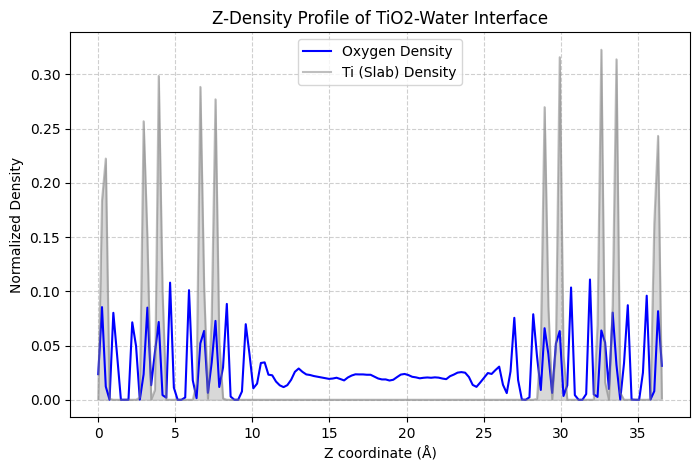

In [8]:
"""
Script 2: Z-Density Profile (Interfacial Structuring)
Purpose: Calculates the density of water molecules along the Z-axis (perpendicular to the
TiO2 surface). This identifies highly structured water layers physically adsorbed to the anatase.
"""

import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

# --- USER CONFIGURATION ---
TRAJECTORY_FILE = '/content/MPtrj/dissociated/Anatase_wrapped.extxyz'
NBINS = 150
# --------------------------

def calculate_z_density():
    print(f"Reading trajectory from {TRAJECTORY_FILE}...")
    traj = read(TRAJECTORY_FILE, index=':')

    start_frame = int(len(traj) * 0.5) # Use last 50%
    analyzed_frames = traj[start_frame:]

    z_coords_water_O = []
    z_coords_Ti = []

    # Extract Z-axis size from the first frame to set histogram range
    cell_z = analyzed_frames[0].get_cell()[2, 2]

    print("Extracting Z coordinates...")
    for atoms in analyzed_frames:
        symbols = atoms.get_chemical_symbols()
        positions = atoms.get_positions()

        for i, sym in enumerate(symbols):
            # Assuming 'Ti' is the slab and 'O' belongs to water/slab
            if sym == 'Ti':
                z_coords_Ti.append(positions[i, 2])
            elif sym == 'O':
                # Note: In a real script, filter out slab Oxygen vs Water Oxygen
                # using indices or tags if available in the extxyz.
                z_coords_water_O.append(positions[i, 2])

    # Create Histograms
    hist_O, bins_O = np.histogram(z_coords_water_O, bins=NBINS, range=(0, cell_z), density=True)
    hist_Ti, bins_Ti = np.histogram(z_coords_Ti, bins=NBINS, range=(0, cell_z), density=True)

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(bins_O[:-1], hist_O, color='blue', label='Oxygen Density')
    plt.plot(bins_Ti[:-1], hist_Ti, color='grey', alpha=0.5, label='Ti (Slab) Density')
    plt.fill_between(bins_Ti[:-1], 0, hist_Ti, color='grey', alpha=0.3)

    plt.title('Z-Density Profile of TiO2-Water Interface')
    plt.xlabel('Z coordinate (Å)')
    plt.ylabel('Normalized Density')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('02_Z_Density_Profile.png', dpi=300)
    print("Saved Z-Density plot to 02_Z_Density_Profile.png")

if __name__ == "__main__":
    try:
        calculate_z_density()
    except FileNotFoundError:
         print(f"Error: Could not find {TRAJECTORY_FILE}.")

Reading trajectory from /content/MPtrj/dissociated/Anatase_wrapped.extxyz...
Calculating Mean Squared Displacement...
Estimated Diffusion Coefficient: 0.0268 Å²/ps
Saved MSD plot to 03_Water_MSD.png


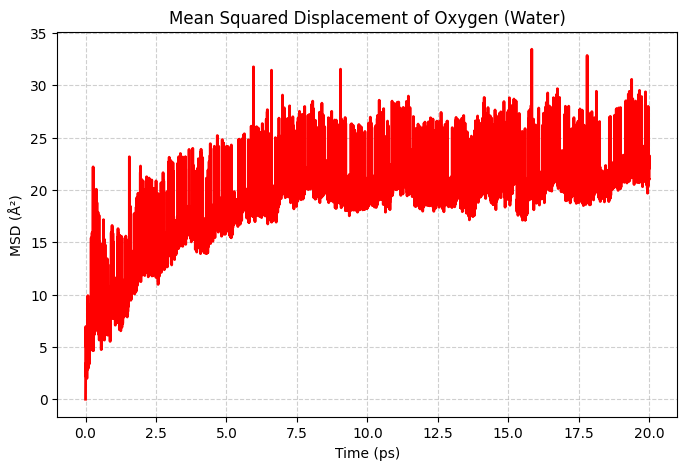

In [9]:
"""
Script 3: Mean Squared Displacement (MSD) & Diffusion Coefficient
Purpose: Measures how far water molecules travel over time. Free bulk water will have a linear
MSD slope, while water trapped/adsorbed on the anatase surface will plateau.
"""

import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

# --- USER CONFIGURATION ---
TRAJECTORY_FILE = '/content/MPtrj/dissociated/Anatase_wrapped.extxyz'
DT = 1.0 # Time step between frames in femtoseconds (Adjust based on your MD run)
# --------------------------

def calculate_msd():
    print(f"Reading trajectory from {TRAJECTORY_FILE}...")
    traj = read(TRAJECTORY_FILE, index=':')

    # Identify indices of Oxygen atoms (representing water molecules)
    # Ideally, you filter out the slab oxygens. For simplicity, we track all 'O'.
    symbols = np.array(traj[0].get_chemical_symbols())
    o_indices = np.where(symbols == 'O')[0]

    n_frames = len(traj)
    n_atoms = len(o_indices)

    # Extract positions of selected atoms across all frames
    positions = np.zeros((n_frames, n_atoms, 3))
    for i, atoms in enumerate(traj):
        positions[i] = atoms.get_positions()[o_indices]

    print("Calculating Mean Squared Displacement...")
    msd = np.zeros(n_frames)

    # Calculate MSD relative to the first frame (t=0)
    pos_t0 = positions[0]
    for t in range(n_frames):
        diff = positions[t] - pos_t0
        # Calculate squared distance sum across x, y, z
        sq_dist = np.sum(diff**2, axis=1)
        msd[t] = np.mean(sq_dist)

    time_axis = np.arange(n_frames) * DT / 1000.0 # Convert fs to picoseconds (ps)

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(time_axis, msd, color='red', lw=2)
    plt.title('Mean Squared Displacement of Oxygen (Water)')
    plt.xlabel('Time (ps)')
    plt.ylabel('MSD (Å²)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('03_Water_MSD.png', dpi=300)

    # Estimate Diffusion Coefficient (D = slope / 6)
    # Using the linear regime (e.g., latter half of the simulation)
    linear_fit = np.polyfit(time_axis[int(n_frames/2):], msd[int(n_frames/2):], 1)
    diffusion_coeff = linear_fit[0] / 6.0
    print(f"Estimated Diffusion Coefficient: {diffusion_coeff:.4f} Å²/ps")
    print("Saved MSD plot to 03_Water_MSD.png")

if __name__ == "__main__":
    try:
        calculate_msd()
    except FileNotFoundError:
         print(f"Error: Could not find {TRAJECTORY_FILE}.")

Reading trajectory from /content/MPtrj/dissociated/Anatase_wrapped.extxyz...
Trajectory loaded. Found 20000 frames.
Firing up Multiprocessing on 2 CPU cores...


Processing frames (Parallel): 100%|██████████| 20000/20000 [07:11<00:00, 46.40it/s]



Saved Coordination plot to 04_Ti_Coordination.png


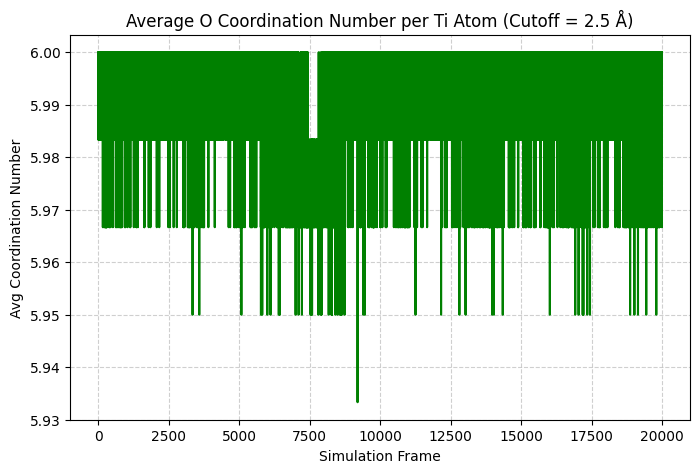

In [14]:
"""
Script 4: Surface Coordination / Adsorption Sites (OPTIMIZED + MULTIPROCESSING)
Purpose: Counts how many water molecules are directly bonded to the Titanium surface atoms.
Optimization 1: Uses ASE's C-accelerated neighbor_list.
Optimization 2: Uses ProcessPoolExecutor to analyze multiple frames simultaneously across all CPU cores.
"""

import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from ase.neighborlist import neighbor_list
from tqdm import tqdm
import multiprocessing
from concurrent.futures import ProcessPoolExecutor

# --- USER CONFIGURATION ---
TRAJECTORY_FILE = '/content/MPtrj/dissociated/Anatase_wrapped.extxyz'
CUTOFF_RADIUS = 2.5 # Angstroms - typical max distance for a Ti-O chemical/adsorption bond
# --------------------------

def process_single_frame(args):
    """
    Helper function to process a single frame.
    Must be defined at the top level for multiprocessing to pickle it properly.
    """
    frame_idx, atoms = args
    symbols = np.array(atoms.get_chemical_symbols())
    num_ti = np.sum(symbols == 'Ti')

    if num_ti == 0:
        return frame_idx, 0.0

    # C-accelerated neighbor list
    i_indices, j_indices = neighbor_list('ij', atoms, CUTOFF_RADIUS)

    # Vectorized NumPy array filtering
    ti_mask = symbols[i_indices] == 'Ti'
    o_mask = symbols[j_indices] == 'O'

    total_ti_o_bonds = np.sum(ti_mask & o_mask)
    avg_coord_per_ti = total_ti_o_bonds / num_ti

    return frame_idx, avg_coord_per_ti

def calculate_coordination():
    print(f"Reading trajectory from {TRAJECTORY_FILE}...")
    # Read the trajectory into memory.
    # (If the file is massive, consider using ase.io.iread and chunking, but for most this is fine)
    traj = read(TRAJECTORY_FILE, index=':')

    num_cores = multiprocessing.cpu_count()
    print(f"Trajectory loaded. Found {len(traj)} frames.")
    print(f"Firing up Multiprocessing on {num_cores} CPU cores...")

    # Prepare arguments for the worker pool
    args_list = [(i, atoms) for i, atoms in enumerate(traj)]

    frames = []
    avg_coordination_list = []

    # Run in parallel
    with ProcessPoolExecutor(max_workers=num_cores) as executor:
        # executor.map guarantees that the results are returned in the original order
        results = list(tqdm(executor.map(process_single_frame, args_list),
                            total=len(args_list),
                            desc="Processing frames (Parallel)"))

    # Unpack the results
    for frame_idx, avg_coord in results:
        frames.append(frame_idx)
        avg_coordination_list.append(avg_coord)

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(frames, avg_coordination_list, color='green', lw=1.5)
    plt.title(f'Average O Coordination Number per Ti Atom (Cutoff = {CUTOFF_RADIUS} Å)')
    plt.xlabel('Simulation Frame')
    plt.ylabel('Avg Coordination Number')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('04_Ti_Coordination.png', dpi=300)
    print("\nSaved Coordination plot to 04_Ti_Coordination.png")

    # Save raw data
    data_out = np.column_stack((frames, avg_coordination_list))
    np.savetxt('04_coordination_data.csv', data_out, delimiter=',', header='Frame,Avg_Coordination')

if __name__ == "__main__":
    try:
        calculate_coordination()
    except FileNotFoundError:
         print(f"Error: Could not find {TRAJECTORY_FILE}.")

Reading trajectory from /content/MPtrj/dissociated/Anatase_wrapped.extxyz...

Extracting thermodynamic data...

ASE 'info' dictionary missing energy data. Performing robust manual regex parsing...
Manually extracted 20000 frame headers via regex.

--- ENERGY CALCULATIONS ---


Processing Frames:   8%|▊         | 1565/20000 [00:00<00:01, 15645.87it/s]

Frame 0000: Total Energy = -2798.796143 eV | Free Energy = -2798.796143 eV | Atoms = 426 | Per-Atom Energy = -6.569944 eV/atom
Frame 0001: Total Energy = -2809.045654 eV | Free Energy = -2809.045654 eV | Atoms = 426 | Per-Atom Energy = -6.594004 eV/atom
Frame 0002: Total Energy = -2809.089355 eV | Free Energy = -2809.089355 eV | Atoms = 426 | Per-Atom Energy = -6.594106 eV/atom
Frame 0003: Total Energy = -2808.613525 eV | Free Energy = -2808.613525 eV | Atoms = 426 | Per-Atom Energy = -6.592989 eV/atom
Frame 0004: Total Energy = -2808.223877 eV | Free Energy = -2808.223877 eV | Atoms = 426 | Per-Atom Energy = -6.592075 eV/atom
...
(Energy calculations continuing for remaining frames...)


Processing Frames: 100%|██████████| 20000/20000 [00:00<00:00, 36233.45it/s]



Saving extraction results to CSV...
Saved Stability plot to 05_System_Stability.png and data to 05_thermodynamic_data.csv


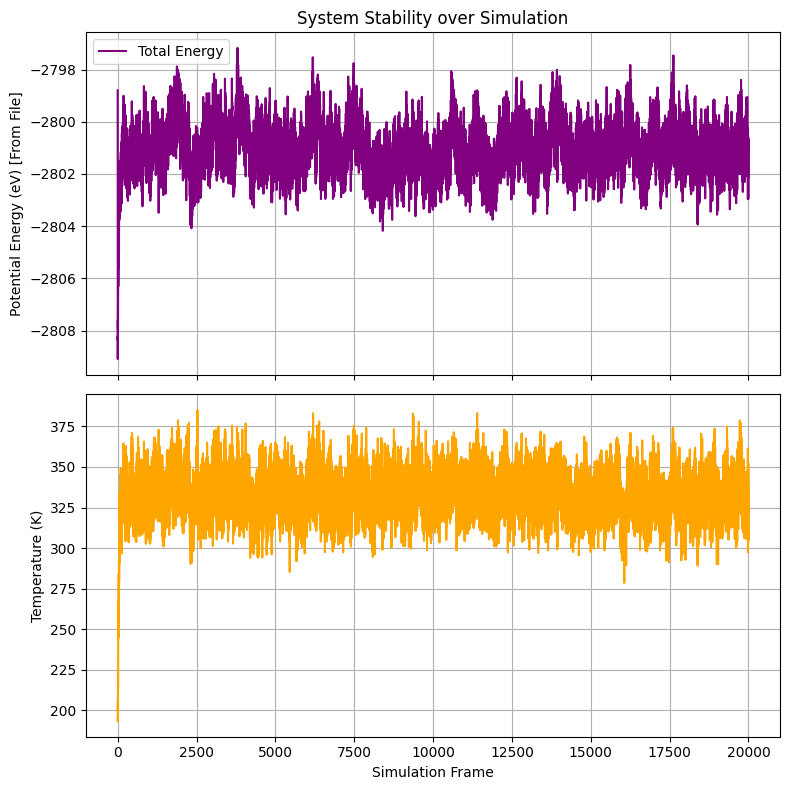

In [1]:
"""
Script 5: Energy, Temperature & Stability Extractor (ROBUST VERSION)
Purpose: Parses the extended XYZ header information over time to extract potential energy
and temperature.

*UPDATED*: Now features a robust manual Regex fallback. If ASE fails to parse the
extxyz header properly into the atoms.info dictionary, it will manually scan the text
file to guarantee extraction of 'energy' and 'free_energy'.
"""

import matplotlib.pyplot as plt
from ase.io import read
import pandas as pd
import numpy as np
import re
from tqdm import tqdm

# --- USER CONFIGURATION ---
TRAJECTORY_FILE = '/content/MPtrj/dissociated/Anatase_wrapped.extxyz'

# Toggle this to True if you want to recalculate the energy using MACE
# instead of reading it from the top line of the extxyz file.
USE_MACE_CALCULATOR = False
MACE_MODEL = "medium"  # Options: "small", "medium", "large"
MACE_DEVICE = "cuda"   # Options: "cuda" (for GPU) or "cpu"
# --------------------------

def track_stability():
    print(f"Reading trajectory from {TRAJECTORY_FILE}...")
    # Force extxyz format explicitly
    traj = read(TRAJECTORY_FILE, index=':', format='extxyz')

    energies = []
    free_energies = []
    per_atom_energies = []
    temperatures = []
    frames = []

    # Initialize MACE Calculator if requested
    calc = None
    if USE_MACE_CALCULATOR:
        print(f"\nLoading MACE-MP ({MACE_MODEL}) calculator on {MACE_DEVICE}...")
        try:
            from mace.calculators import mace_mp
            calc = mace_mp(model=MACE_MODEL, dispersion=False, default_dtype="float64", device=MACE_DEVICE)
            print("MACE calculator loaded successfully.")
        except ImportError:
            print("\nERROR: 'mace-torch' is not installed.")
            print("Please run `pip install mace-torch` or set USE_MACE_CALCULATOR = False.")
            return

    print("\nExtracting thermodynamic data...")

    # --- MANUAL REGEX FALLBACK PRE-PROCESSING ---
    manual_energies = []
    manual_free_energies = []

    if len(traj) > 0 and not USE_MACE_CALCULATOR:
        # Check if ASE successfully grabbed the energy in the first frame
        info_keys = [k.lower() for k in traj[0].info.keys()]
        if not any(k in info_keys for k in ['energy', 'e', 'potentialenergy']):
            print("\nASE 'info' dictionary missing energy data. Performing robust manual regex parsing...")
            with open(TRAJECTORY_FILE, 'r') as f:
                for line in f:
                    # Identify header lines (usually contain Lattice, Properties, or energy=)
                    if 'Lattice=' in line or 'Properties=' in line or 'energy=' in line:
                        # Extract energy using Regex
                        e_match = re.search(r'\b(?:energy|E)=([-+]?[0-9]*\.?[0-9]+(?:[eE][-+]?[0-9]+)?)', line)
                        manual_energies.append(float(e_match.group(1)) if e_match else None)

                        # Extract free_energy using Regex
                        fe_match = re.search(r'\bfree_energy=([-+]?[0-9]*\.?[0-9]+(?:[eE][-+]?[0-9]+)?)', line)
                        manual_free_energies.append(float(fe_match.group(1)) if fe_match else None)

            print(f"Manually extracted {len(manual_energies)} frame headers via regex.\n")
        else:
            print(f"\n--- EXTXYZ FILE DIAGNOSTICS ---")
            print(f"Header Keys (info) successfully parsed: {list(traj[0].info.keys())}")
            print("-------------------------------\n")

    print("--- ENERGY CALCULATIONS ---")
    for i, atoms in enumerate(tqdm(traj, desc="Processing Frames")):
        info = atoms.info
        frames.append(i)

        # 1. Robust Energy Extraction
        energy = None
        free_energy = None

        if USE_MACE_CALCULATOR:
            # Re-run the MACE model to find the energy dynamically
            atoms.calc = calc
            energy = atoms.get_potential_energy()
        else:
            # If manual fallback was triggered, use those values
            if len(manual_energies) > i:
                energy = manual_energies[i]
                free_energy = manual_free_energies[i] if i < len(manual_free_energies) else None
            else:
                # Otherwise, find the energy from the info dictionary parsed by ASE
                if 'energy' in info:
                    energy = float(info['energy'])
                elif 'E' in info:
                    energy = float(info['E'])

                if 'free_energy' in info:
                    free_energy = float(info['free_energy'])

        energies.append(energy)
        free_energies.append(free_energy)

        # Calculate per-atom energy
        num_atoms = len(atoms)
        per_atom_energy = energy / num_atoms if energy is not None else None
        per_atom_energies.append(per_atom_energy)

        # Show the energy calculations for the first 5 frames to verify extraction
        if i < 5:
            e_str = f"{energy:.6f}" if energy is not None else "None"
            fe_str = f"{free_energy:.6f}" if free_energy is not None else "None"
            pae_str = f"{per_atom_energy:.6f}" if per_atom_energy is not None else "None"
            tqdm.write(f"Frame {i:04d}: Total Energy = {e_str} eV | Free Energy = {fe_str} eV | "
                       f"Atoms = {num_atoms} | Per-Atom Energy = {pae_str} eV/atom")
        elif i == 5:
            tqdm.write("...\n(Energy calculations continuing for remaining frames...)")

        # 2. Robust Temperature Extraction
        temp = None
        # Check header keys first
        for key in ['T', 'temp', 'temperature', 'Temperature', 'kinTemp']:
            if key in info:
                temp = float(info[key])
                break

        # If not in header, try calculating from velocities
        if temp is None:
            try:
                calc_temp = atoms.get_temperature()
                if calc_temp > 0.0:
                    temp = calc_temp
            except Exception:
                pass

        temperatures.append(temp)

    # Save to CSV using Pandas for easy viewing
    print("\nSaving extraction results to CSV...")
    df = pd.DataFrame({
        'Frame': frames,
        'Total_Energy_eV': energies,
        'Free_Energy_eV': free_energies,
        'Per_Atom_Energy_eV': per_atom_energies,
        'Temperature_K': temperatures
    })
    df.to_csv('05_thermodynamic_data.csv', index=False)

    # Plotting Energy and Temperature on two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # Filter out None values before plotting to prevent matplotlib from breaking
    valid_energy_frames = [f for f, e in zip(frames, energies) if e is not None]
    valid_energies = [e for e in energies if e is not None]

    valid_temp_frames = [f for f, t in zip(frames, temperatures) if t is not None]
    valid_temps = [t for t in temperatures if t is not None]

    if valid_energies:
        ax1.plot(valid_energy_frames, valid_energies, color='purple', label='Total Energy')
        ylabel = 'Potential Energy (eV) [MACE Recalculated]' if USE_MACE_CALCULATOR else 'Potential Energy (eV) [From File]'
        ax1.set_ylabel(ylabel)
        ax1.set_title('System Stability over Simulation')
        ax1.grid(True)
        ax1.legend()
    else:
        ax1.text(0.5, 0.5, "Energy data missing in extxyz headers.\nEnsure your file contains 'energy=' tags.",
                 ha='center', va='center', transform=ax1.transAxes)

    if valid_temps:
        ax2.plot(valid_temp_frames, valid_temps, color='orange')
        ax2.set_ylabel('Temperature (K)')
        ax2.set_xlabel('Simulation Frame')
        ax2.grid(True)
    else:
        ax2.text(0.5, 0.5, "Velocity/Temp data missing in extxyz headers/arrays.\nCheck diagnostic printout.",
                 ha='center', va='center', transform=ax2.transAxes)

    plt.tight_layout()
    plt.savefig('05_System_Stability.png', dpi=300)
    print("Saved Stability plot to 05_System_Stability.png and data to 05_thermodynamic_data.csv")

if __name__ == "__main__":
    try:
        track_stability()
    except FileNotFoundError:
         print(f"Error: Could not find {TRAJECTORY_FILE}.")

Reading trajectory from /content/MPtrj/dissociated/Anatase_wrapped.extxyz...
Extracting water positions within 5.0 Å of the surface (Z ~ 36.39)...
Saved 2D density map to 06_2D_Wettability_Map.png


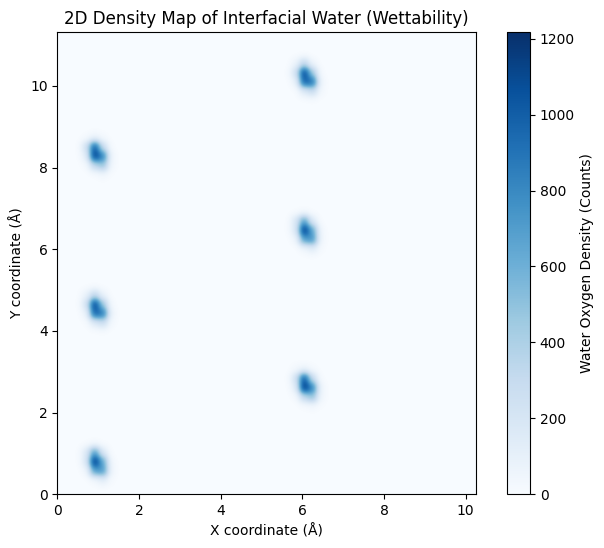

In [15]:
"""
Script 6: 2D Water Density Map (Wettability/Coating Uniformity)
Purpose: Projects the position of water molecules onto the XY plane (parallel to the TiO2 surface).
A uniform distribution indicates good wetting (hydrophilicity), while clustered areas
indicate droplet formation or poor wetting on specific crystal facets.
"""

import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

# --- USER CONFIGURATION ---
TRAJECTORY_FILE = '/content/MPtrj/dissociated/Anatase_wrapped.extxyz'
NBINS = 50       # Grid resolution for the 2D map
Z_CUTOFF = 5.0   # Only look at water within 5 Angstroms of the surface
# --------------------------

def calculate_2d_density():
    print(f"Reading trajectory from {TRAJECTORY_FILE}...")
    traj = read(TRAJECTORY_FILE, index=':')

    # Use the last 30% of the trajectory to ensure equilibration
    start_frame = int(len(traj) * 0.7)
    analyzed_frames = traj[start_frame:]

    # Get cell dimensions from the first frame
    cell = analyzed_frames[0].get_cell()
    x_max = cell[0, 0]
    y_max = cell[1, 1]

    # Estimate the surface Z-coordinate by finding the highest Ti atom
    first_frame_symbols = np.array(analyzed_frames[0].get_chemical_symbols())
    first_frame_pos = analyzed_frames[0].get_positions()
    ti_indices = np.where(first_frame_symbols == 'Ti')[0]
    surface_z = np.max(first_frame_pos[ti_indices, 2])

    x_coords = []
    y_coords = []

    print(f"Extracting water positions within {Z_CUTOFF} Å of the surface (Z ~ {surface_z:.2f})...")
    for atoms in analyzed_frames:
        symbols = np.array(atoms.get_chemical_symbols())
        positions = atoms.get_positions()

        # Filter for Oxygen atoms (representing water, ideally filter out slab oxygens)
        o_indices = np.where(symbols == 'O')[0]

        for idx in o_indices:
            pos = positions[idx]
            # If the oxygen is in the water layer just above the slab
            if surface_z < pos[2] < (surface_z + Z_CUTOFF):
                x_coords.append(pos[0])
                y_coords.append(pos[1])

    # Create 2D Histogram
    heatmap, xedges, yedges = np.histogram2d(x_coords, y_coords, bins=NBINS, range=[[0, x_max], [0, y_max]])

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.imshow(heatmap.T, origin='lower', extent=[0, x_max, 0, y_max], cmap='Blues', interpolation='gaussian')
    plt.colorbar(label='Water Oxygen Density (Counts)')
    plt.title('2D Density Map of Interfacial Water (Wettability)')
    plt.xlabel('X coordinate (Å)')
    plt.ylabel('Y coordinate (Å)')
    plt.savefig('06_2D_Wettability_Map.png', dpi=300)
    print("Saved 2D density map to 06_2D_Wettability_Map.png")

if __name__ == "__main__":
    try:
        calculate_2d_density()
    except FileNotFoundError:
        print(f"Error: Could not find {TRAJECTORY_FILE}.")

Reading trajectory from /content/MPtrj/dissociated/Anatase_wrapped.extxyz...
Attempting to extract off-diagonal stress tensors...
ASE 'info' dictionary is empty. Falling back to robust manual text parsing...
Successfully extracted 20000 frames of Pxy stress data.
Calculating Stress Auto-Correlation Function (SACF)...
Saved Viscosity plot. Final estimated viscosity: 0.05 cP


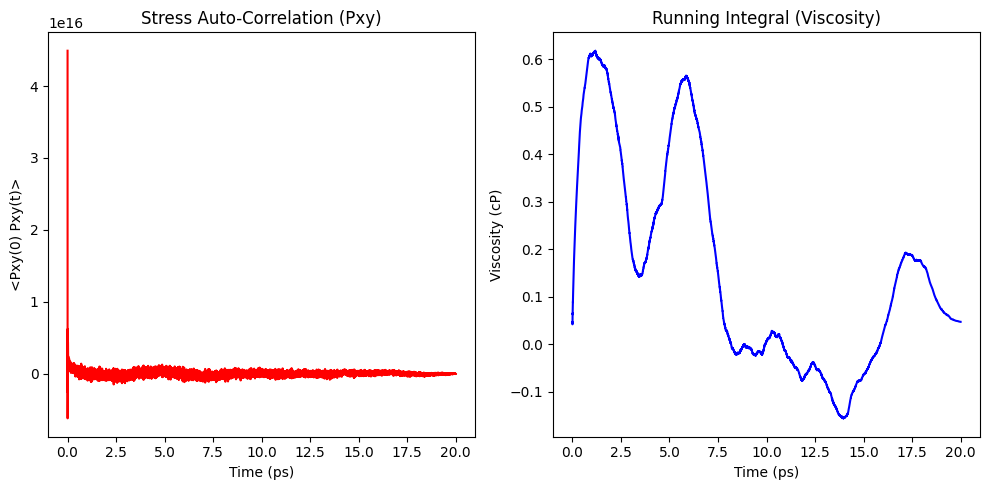

In [25]:
"""
Script 7: Shear Viscosity (Green-Kubo Method)
Purpose: Calculates the shear viscosity of the slurry.
*REQUIREMENT*: The .extxyz file MUST contain the stress tensor ('stress' or 'virial' in atoms.info)
saved at high frequency (e.g., every 1-5 fs) for this to yield accurate results.
"""

import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
import re

# --- USER CONFIGURATION ---
TRAJECTORY_FILE = '/content/MPtrj/dissociated/Anatase_wrapped.extxyz'
DT = 1.0          # Time step between frames in femtoseconds
TEMPERATURE = 300 # Temperature in Kelvin
# --------------------------

# Physical constants for unit conversion
KB = 1.380649e-23  # J/K
EV_TO_JOULES = 1.60217662e-19
ANGSTROM_TO_METERS = 1e-10

def calculate_viscosity():
    print(f"Reading trajectory from {TRAJECTORY_FILE}...")
    # Force extxyz format explicitly
    traj = read(TRAJECTORY_FILE, index=':', format='extxyz')

    P_xy = []
    volume = None

    print("Attempting to extract off-diagonal stress tensors...")

    # Check if ASE successfully parsed the volume
    if traj[0].get_volume() > 0:
        volume = traj[0].get_volume() * (ANGSTROM_TO_METERS**3)

    for i, atoms in enumerate(traj):
        info = atoms.info
        stress = None

        # Robustly search for stress or virial keys (case-insensitive)
        for key in info.keys():
            if 'stress' in key.lower() or 'virial' in key.lower():
                stress = info[key]
                if 'virial' in key.lower():
                    # Convert virial to stress by dividing by volume
                    stress = np.array(stress) / atoms.get_volume()
                break

        if stress is not None:
            # Handle case where stress is read as a space-separated string with possible quotes
            if isinstance(stress, str):
                clean_str = stress.replace('"', '').replace("'", '').replace('[', '').replace(']', '')
                stress_array = np.array([float(x) for x in clean_str.split()])
            else:
                # Flatten in case it's parsed as a 3x3 numpy array or 1D list
                stress_array = np.array(stress).flatten()

            # Depending on the code (VASP, CP2K, LAMMPS), stress array length varies.
            if len(stress_array) == 9:
                # Reshape as 3x3 tensor as requested:
                # [[xx, xy, xz],
                #  [yx, yy, yz],
                #  [zx, zy, zz]]
                stress_3x3 = stress_array.reshape(3, 3)
                pxy_ev_A3 = stress_3x3[0, 1]  # Extract the xy component
            elif len(stress_array) == 6:
                # Voigt notation: [xx, yy, zz, yz, xz, xy]
                # The xy component is at index 5
                pxy_ev_A3 = stress_array[5]
            else:
                if i == 0:
                    print(f"Warning: Unexpected stress array length ({len(stress_array)}). Expected 6 or 9.")
                continue

            # Ensure it is converted to Pascals (if in eV/A^3)
            # 1 eV/A^3 = 1.602e11 Pa
            pxy_pascals = pxy_ev_A3 * 1.60217662e11
            P_xy.append(pxy_pascals)

    # --- MANUAL REGEX FALLBACK ---
    if not P_xy:
        print("ASE 'info' dictionary is empty. Falling back to robust manual text parsing...")
        P_xy = []
        volume_A3 = None

        with open(TRAJECTORY_FILE, 'r') as f:
            for line in f:
                if 'stress=' in line:
                    # Extract Stress using Regex
                    stress_match = re.search(r'stress="([^"]+)"', line)
                    if stress_match:
                        stress_array = np.array([float(x) for x in stress_match.group(1).split()])
                        if len(stress_array) == 9:
                            stress_3x3 = stress_array.reshape(3, 3)
                            pxy_ev_A3 = stress_3x3[0, 1]
                        elif len(stress_array) == 6:
                            pxy_ev_A3 = stress_array[5]
                        else:
                            continue

                        pxy_pascals = pxy_ev_A3 * 1.60217662e11
                        P_xy.append(pxy_pascals)

                    # Extract Lattice for volume if ASE failed to get it
                    if volume_A3 is None and 'Lattice=' in line:
                        lattice_match = re.search(r'Lattice="([^"]+)"', line)
                        if lattice_match:
                            lat_vals = [float(x) for x in lattice_match.group(1).split()]
                            if len(lat_vals) == 9:
                                matrix = np.array(lat_vals).reshape(3, 3)
                                volume_A3 = np.abs(np.linalg.det(matrix))

        if volume_A3 is not None:
            volume = volume_A3 * (ANGSTROM_TO_METERS**3)

    # --- FINAL VALIDATION ---
    if not P_xy:
        print("ERROR: Could not find 'stress' or 'virial' data in the extxyz file.")
        print("To calculate viscosity, ensure your MD engine outputs stress tensors.")
        if len(traj) > 0:
            print(f"Diagnostic - Available keys in Frame 0 headers: {list(traj[0].info.keys())}")
        return

    if volume is None or volume == 0:
        print("ERROR: Could not determine simulation cell volume.")
        return

    P_xy = np.array(P_xy)
    n_frames = len(P_xy)

    print(f"Successfully extracted {n_frames} frames of Pxy stress data.")
    print("Calculating Stress Auto-Correlation Function (SACF)...")

    # Calculate Autocorrelation
    sacf = np.correlate(P_xy, P_xy, mode='full')[n_frames-1:]
    sacf /= n_frames # Normalize

    time_axis = np.arange(len(sacf)) * DT * 1e-15 # in seconds

    # Integrate SACF to get viscosity (Green-Kubo integral)
    # Eta = (V / (kB * T)) * integral(SACF dt)
    integral_sacf = np.cumsum(sacf) * (DT * 1e-15)
    viscosity = (volume / (KB * TEMPERATURE)) * integral_sacf

    # Convert viscosity to milliPascal-seconds (mPa*s), equivalent to centiPoise (cP)
    viscosity_cp = viscosity * 1000

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.plot(time_axis * 1e12, sacf, color='red') # time in ps
    plt.title('Stress Auto-Correlation (Pxy)')
    plt.xlabel('Time (ps)')
    plt.ylabel('<Pxy(0) Pxy(t)>')

    plt.subplot(1, 2, 2)
    plt.plot(time_axis * 1e12, viscosity_cp, color='blue')
    plt.title('Running Integral (Viscosity)')
    plt.xlabel('Time (ps)')
    plt.ylabel('Viscosity (cP)')

    plt.tight_layout()
    plt.savefig('07_Shear_Viscosity.png', dpi=300)
    print(f"Saved Viscosity plot. Final estimated viscosity: {viscosity_cp[-1]:.2f} cP")

if __name__ == "__main__":
    try:
        calculate_viscosity()
    except FileNotFoundError:
        print(f"Error: Could not find {TRAJECTORY_FILE}.")

Reading trajectory from /content/MPtrj/dissociated/Anatase_wrapped.extxyz...
Trajectory loaded. Found 20000 frames.
Firing up Multiprocessing on 2 CPU cores...


Processing H-Bonds (Parallel): 100%|██████████| 20000/20000 [07:26<00:00, 44.79it/s]



Saved H-Bond plot to 08_Hydrogen_Bonds.png


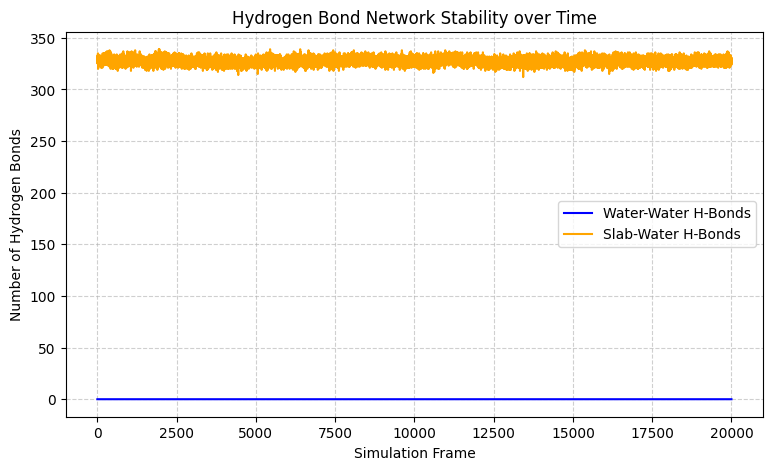

In [2]:
"""
Script 8: Hydrogen Bond Network & Agglomeration Potential (OPTIMIZED + MULTIPROCESSING)
Purpose: Counts the number of hydrogen bonds between water molecules and the TiO2 slab over time.
A stable, non-fluctuating H-bond count implies a stable hydration shell, which prevents
particles from agglomerating (flocculating) in industrial slurries.

Optimization: Uses multiprocessing and ASE's neighbor_list for massive speedup.
"""

import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from ase.neighborlist import neighbor_list
from tqdm import tqdm
import multiprocessing
from concurrent.futures import ProcessPoolExecutor

# --- USER CONFIGURATION ---
TRAJECTORY_FILE = '/content/MPtrj/dissociated/Anatase_wrapped.extxyz'
O_H_CUTOFF = 2.45  # Max distance for a Hydrogen bond (Angstroms)
# --------------------------

def process_single_frame(args):
    """
    Helper function to process a single frame for hydrogen bond counting.
    Must be defined at the top level for multiprocessing to pickle it properly.
    """
    frame_idx, atoms = args
    symbols = np.array(atoms.get_chemical_symbols())

    # Check if Hydrogens are present in the simulation
    if 'H' not in symbols:
        return frame_idx, -1, -1 # Error flags

    # Use ASE neighbor list to find pairs within cutoff
    # i_indices: index of first atom, j_indices: index of second atom
    i_indices, j_indices = neighbor_list('ij', atoms, O_H_CUTOFF)

    w_w_count = 0
    s_w_count = 0

    # Determine which oxygens belong to the slab vs water based on Z-height
    # (This is a simplified heuristic. Adjust based on your exact slab height).
    z_positions = atoms.get_positions()[:, 2]
    ti_indices = np.where(symbols == 'Ti')[0]
    max_slab_z = np.max(z_positions[ti_indices]) + 1.0 if len(ti_indices) > 0 else 0

    # Iterate through bonded pairs
    for idx in range(len(i_indices)):
        atom1_idx = i_indices[idx]
        atom2_idx = j_indices[idx]

        sym1 = symbols[atom1_idx]
        sym2 = symbols[atom2_idx]

        # Look for O-H or H-O pairs
        if (sym1 == 'O' and sym2 == 'H') or (sym1 == 'H' and sym2 == 'O'):
            o_idx = atom1_idx if sym1 == 'O' else atom2_idx

            # Check if this Oxygen belongs to the slab or to a water molecule
            is_slab_oxygen = z_positions[o_idx] < max_slab_z

            # To prevent double counting (i->j and j->i), we only count when atom1 < atom2
            if atom1_idx < atom2_idx:
                if is_slab_oxygen:
                    s_w_count += 1
                else:
                    w_w_count += 1

    return frame_idx, w_w_count, s_w_count

def analyze_h_bonds():
    print(f"Reading trajectory from {TRAJECTORY_FILE}...")
    traj = read(TRAJECTORY_FILE, index=':')

    num_cores = multiprocessing.cpu_count()
    print(f"Trajectory loaded. Found {len(traj)} frames.")
    print(f"Firing up Multiprocessing on {num_cores} CPU cores...")

    # Prepare arguments for the worker pool
    args_list = [(i, atoms) for i, atoms in enumerate(traj)]

    frames = []
    water_water_hbonds = []
    slab_water_hbonds = []

    # Run in parallel
    with ProcessPoolExecutor(max_workers=num_cores) as executor:
        # executor.map guarantees that the results are returned in the original order
        results = list(tqdm(executor.map(process_single_frame, args_list),
                            total=len(args_list),
                            desc="Processing H-Bonds (Parallel)"))

    # Unpack the results
    for frame_idx, w_w_count, s_w_count in results:
        if w_w_count == -1:
            print("ERROR: No Hydrogen atoms found in trajectory. Cannot compute H-bonds.")
            return

        frames.append(frame_idx)
        water_water_hbonds.append(w_w_count)
        slab_water_hbonds.append(s_w_count)

    # Plotting
    plt.figure(figsize=(9, 5))
    plt.plot(frames, water_water_hbonds, label='Water-Water H-Bonds', color='blue')
    plt.plot(frames, slab_water_hbonds, label='Slab-Water H-Bonds', color='orange')

    plt.title('Hydrogen Bond Network Stability over Time')
    plt.xlabel('Simulation Frame')
    plt.ylabel('Number of Hydrogen Bonds')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('08_Hydrogen_Bonds.png', dpi=300)
    print("\nSaved H-Bond plot to 08_Hydrogen_Bonds.png")

if __name__ == "__main__":
    try:
        analyze_h_bonds()
    except FileNotFoundError:
        print(f"Error: Could not find {TRAJECTORY_FILE}.")

Reading trajectory from /content/MPtrj/dissociated/Anatase_wrapped.extxyz...
Extracting water dipoles in the first hydration layer...
Saved Dipole Orientation plot to 09_Dipole_Orientation.png


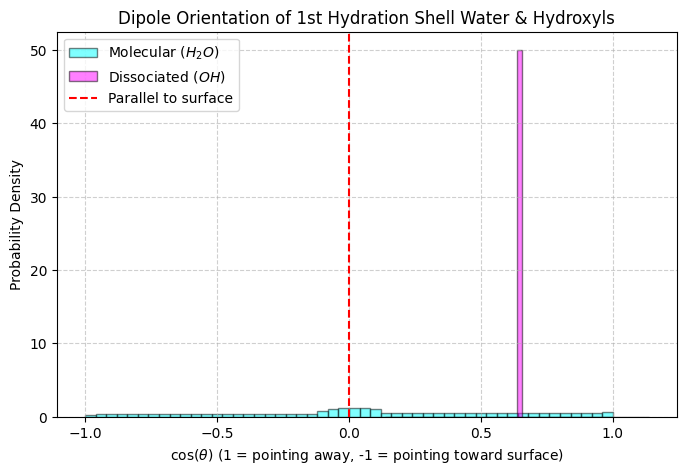

In [3]:
"""
Script 9: Water Dipole Orientation Angle
Purpose: Calculates the orientation of water molecules relative to the TiO2 surface normal (Z-axis).
Plots the distribution of cos(theta) for water molecules in the first hydration shell.
"""

import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from ase.neighborlist import neighbor_list

# --- USER CONFIGURATION ---
TRAJECTORY_FILE = '/content/MPtrj/dissociated/Anatase_wrapped.extxyz'
SURFACE_Z_APPROX = 15.0 # Approximate Z coordinate of the top TiO2 slab layer
SHELL_THICKNESS = 3.5   # Thickness of the first hydration shell to analyze (Angstroms)
# --------------------------

def calculate_dipole_orientations():
    print(f"Reading trajectory from {TRAJECTORY_FILE}...")
    traj = read(TRAJECTORY_FILE, index=':')

    start_frame = int(len(traj) * 0.5) # Use last 50%
    analyzed_frames = traj[start_frame:]

    cos_thetas_mol = []
    cos_thetas_dissoc = []

    print("Extracting water dipoles in the first hydration layer...")
    for atoms in analyzed_frames:
        symbols = np.array(atoms.get_chemical_symbols())
        positions = atoms.get_positions()

        # Find O-H bonds to reconstruct water molecules
        i_indices, j_indices = neighbor_list('ij', atoms, 1.2) # 1.2 A is typical max for intact O-H covalent bond

        o_indices = np.where(symbols == 'O')[0]

        for o_idx in o_indices:
            # Check if this O is in the target hydration layer
            z_pos = positions[o_idx, 2]
            if not (SURFACE_Z_APPROX < z_pos < (SURFACE_Z_APPROX + SHELL_THICKNESS)):
                continue

            # Find hydrogens bonded to this oxygen
            bonded_atoms = j_indices[i_indices == o_idx]
            h_indices = [idx for idx in bonded_atoms if symbols[idx] == 'H']

            # Molecular Water (1 O, 2 H)
            if len(h_indices) == 2:
                o_pos = positions[o_idx]
                h1_pos = positions[h_indices[0]]
                h2_pos = positions[h_indices[1]]

                # Calculate dipole vector (pointing from O to the midpoint of the two H's)
                h_midpoint = (h1_pos + h2_pos) / 2.0
                dipole_vec = h_midpoint - o_pos

                # Normalize the dipole vector
                dipole_norm = np.linalg.norm(dipole_vec)
                if dipole_norm > 0:
                    dipole_unit = dipole_vec / dipole_norm

                    # The surface normal is the Z-axis [0, 0, 1]
                    # The dot product of a unit vector with [0,0,1] is just the Z-component
                    cos_theta = dipole_unit[2]
                    cos_thetas_mol.append(cos_theta)

            # Dissociated Water / Hydroxyl (1 O, 1 H)
            elif len(h_indices) == 1:
                o_pos = positions[o_idx]
                h_pos = positions[h_indices[0]]

                # Vector points from O to H
                dipole_vec = h_pos - o_pos

                dipole_norm = np.linalg.norm(dipole_vec)
                if dipole_norm > 0:
                    dipole_unit = dipole_vec / dipole_norm
                    cos_theta = dipole_unit[2]
                    cos_thetas_dissoc.append(cos_theta)

    # Plotting
    plt.figure(figsize=(8, 5))
    plt.hist(cos_thetas_mol, bins=50, density=True, color='cyan', edgecolor='black', alpha=0.5, label='Molecular ($H_2O$)')

    if len(cos_thetas_dissoc) > 0:
        plt.hist(cos_thetas_dissoc, bins=50, density=True, color='magenta', edgecolor='black', alpha=0.5, label='Dissociated ($OH$)')

    plt.title('Dipole Orientation of 1st Hydration Shell Water & Hydroxyls')
    plt.xlabel(r'$\cos(\theta)$ (1 = pointing away, -1 = pointing toward surface)')
    plt.ylabel('Probability Density')
    plt.axvline(0, color='red', linestyle='--', label='Parallel to surface')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig('09_Dipole_Orientation.png', dpi=300)
    print("Saved Dipole Orientation plot to 09_Dipole_Orientation.png")

if __name__ == "__main__":
    try:
        calculate_dipole_orientations()
    except FileNotFoundError:
        print(f"Error: Could not find {TRAJECTORY_FILE}.")